# **INTRODUCTION TO DEEP LEARING**
___

**MATERIALS**
1. [Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus](#1)
    - [Konsep MLP](#11)
    - [Studi Kasus](#12)
2. [Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus](#2)
    - [Konsep CNN](#21)
    - [Studi Kasus](#22)
3. [Penerapan MLP dan CNN pada dataset CIFAR10](#3)
    - [MLP CIFAR object classifier](#31)
    - [CNN CIFAR object classifier 1](#32)
    - [CNN CIFAR object classifier 2](#32)
4. [Kesimpulan dan Bacaan Lanjutan](#4)
    - [Bacaan Lanjutan](#41)

---

**SOURCES AND LIBRARIES**
1. Tensorflow Keras:
    - Ver. 2.12.0
    - Documentations: https://www.tensorflow.org/versions/r2.12/api_docs/python/tf
    - Github: https://github.com/tensorflow/tensorflow
2. Tensorflow Datasets:
    - Ver. 2.9.9
    - Documentations: https://www.tensorflow.org/datasets/overview
    - Github: https://github.com/tensorflow/datasets
2. Datasets
    - CIFAR10: https://www.cs.toronto.edu/~kriz/cifar.html
    - MNIST: https://www.tensorflow.org/datasets/catalog/mnist

---

#### Environment Setup
Sebelum memulai proses eksperimen pada notebook ini, dilakukan konfigurasi environment dan cek ketersediaan GPU serta

In [1]:
import os
import tensorflow as tf
from tensorflow.python.client import device_lib
import numpy as np
from matplotlib import pyplot as plt
import tensorflow_datasets as tfds
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.datasets import mnist, cifar10
import keras


DATA_PATH = "/app/datasets"
CKPT_PATH = "/app/checkpoints"
# save format untuk model checkpoint
SAVE_FORMAT = "h5"
GLOBAL_SEED = 42

# Ignore TensorFlow INFO dan WARNING messages
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" 

tf.keras.utils.set_random_seed(GLOBAL_SEED)
tf.config.experimental.enable_op_determinism()

# Check for GPU availability
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Available: {bool(gpus)}")

if gpus:
    tf.config.set_visible_devices(gpus, 'GPU')
    usage_devices = [gpu.name for gpu in tf.config.list_logical_devices('GPU')]

    devices = device_lib.list_local_devices()
    print("\nUsage Devices:")
    for dev in devices:
        if dev.name in usage_devices and dev.device_type == "GPU":
            print("Device:", dev.name)
            print("Description:", dev.physical_device_desc)

os.makedirs("/app/datasets", exist_ok=True)
os.makedirs("/app/checkpoints", exist_ok=True)

2026-02-19 16:01:37.283552: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


GPU Available: True

Usage Devices:
Device: /device:GPU:0
Description: device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


2026-02-19 16:01:40.681854: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15305 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0
2026-02-19 16:01:40.692075: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1636] Created device /device:GPU:0 with 15305 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


Sebelum memulai proses implementasi, terdapat beberapa fungsi utilitas yang digunakan untuk membantu pengolahan data, visualisasi, serta proses evaluasi model.

In [2]:
# Utility functions

# Function to generate training and validation plots for loss and accuracy
def generate_plot(result):
    plt.figure(figsize=(12, 4))
    for idx, metric in enumerate(["Loss", "Accuracy"]):
        plt.subplot(1, 2, idx+1)
        plt.plot(result.history[metric.lower()], label=f'Training {metric}')
        plt.plot(result.history[f'val_{metric.lower()}'], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(f'{metric}')
        plt.legend()
        plt.title(f'{metric} Over Time')
    plt.show()

# Function to visualize model predictions with confidence scores
def plot_predictions(model, X_vis_norm, X_vis_raw, y_true, img_shape, class_names=None, cmap="gray", title="Predictions vs True Labels"):
    scores = model.predict(X_vis_norm, verbose=0)
    predictions = tf.argmax(scores, axis=1).numpy()

    n = len(X_vis_norm)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(X_vis_raw[i].reshape(img_shape), cmap=cmap)

        pred_id = predictions[i]
        true_id = int(y_true[i])

        # Convert to names if provided
        if class_names is not None:
            pred_label = class_names[pred_id]
            true_label = class_names[true_id]
        else:
            pred_label = pred_id
            true_label = true_id

        conf = scores[i][pred_id] * 100

        axes[i].set_title(
            f"Conf: {conf:.2f}%\n"
            f"Pred: {pred_label}\n"
            f"True: {true_label}"
        )
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


#function to visualize random samples from the dataset
def visualize_data(x, y=None, title="", n=6, class_names=None):
    idx = np.random.choice(len(x), n, replace=False)

    plt.figure(figsize=(12,4))
    
    for i, j in enumerate(idx):
        plt.subplot(1, n, i+1)

        # Handle grayscale vs RGB automatically
        if x[j].ndim == 2 or x[j].shape[-1] == 1:
            plt.imshow(x[j].squeeze(), cmap="gray")
        else:
            plt.imshow(x[j])

        if y is not None:
            label = y[j]
            
            if hasattr(label, "__len__") and not np.isscalar(label):
                label = np.argmax(label)
            if class_names is not None:
                label_text = class_names[int(label)]
            else:
                label_text = str(int(label))
                
            plt.title(label_text)

        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
    
#function to visualize random samples from the dataset with class names
def class_distribution(y_or_ds, name, num_classes=10):
    if isinstance(y_or_ds, tf.data.Dataset):
        y_list = []
        for _, label in y_or_ds:
            y_list.append(int(label.numpy()))
        y = np.array(y_list)
    else:
        y = np.array(y_or_ds).reshape(-1).astype(int)

    counts = np.bincount(y, minlength=num_classes)
    total = len(y)

    print(f"\n{name} class distribution:")
    for i in range(num_classes):
        print(f"Class {i}: {counts[i]:5d}  ({counts[i]/total:.3f})")


<a id="1"></a>
## **1. Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus**
---

<a id=11></a>
### **1.1 Konsep MLP**

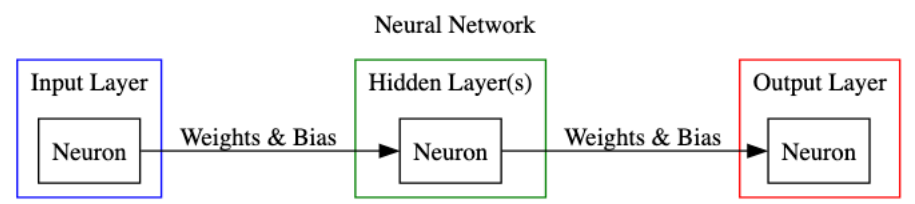

*Multilayer Perceptron (MLP)* merupakan salah satu arsitektur feedforward neural network yang terdiri dari beberapa lapisan (layer) fully connected atau dense layer. Secara umum, MLP memiliki tiga jenis layer, yaitu:

1. **Input Layer**     
Input Layer terdiri dari neuron yang merepresentasikan setiap fitur dalam data. Misalnya, jika teradapat data gambar 28x28 pixel, maka input layer akan memiliki 784 neuron.
    ```python
    input_layer = layers.Input(shape=(SIZE))
    ```

2. **Hidden Layer**    
Hidden layer terdiri dari sejumlah neuron yang melakukan proses komputasi terhadap data menggunakan operasi linear dan fungsi aktivasi non-linear.   
Sebuah MLP dapat memiliki satu atau lebih hidden layer. Jika jumlah hidden layer dari MLP melebihi satu, maka dapat digolongkan dalam kategori Deep Neural Network.
    ```python
    hidden_layer = keras.layers.Dense(128, activation='relu')
    ```

3. **Output Layer**     
Output Layer merupakan layer yang mengahasilkan prediksi akhir dari jaringan. Jumlah neuron yang ada pada output layer bergantung apda jenis permaslahan yang dihadapi.
    ```python
    output_layer = keras.layers.Dense(SIZE, activation="softmax")
    ```

Setiap neuron dalam MLP dihubungkan dengan semua neuron di layer sebelum dan
sesudahnya. Weight dan bias dikaitkan dengan setiap koneksi ini, dan keduanya diupdate
selama proses training.

#### **1.1.1 Proses Training MLP**



MLP dilatih menggunakan **backpropagation** dan **algoritma optimasi** untuk mengupdate weight. Proses training sederhana dapat dijelaskan dalam tiga langkah:

1. **Forward Pass**  
Input dilewatkan melalui semua layer untuk menghasilkan prediksi. Setiap neuron mengubah inputnya menggunakan **fungsi aktivasi**, sehingga model dapat menangkap pola yang kompleks.
Setelah output dihasilkan, **loss function** digunakan untuk mengukur **seberapa jauh prediksi model dari target sebenarnya**.

2. **Backward Pass**  
Setelah loss dihitung, gradien dihitung menggunakan **backpropagation**. Gradien ini menunjukkan seberapa besar weight dan bias memengaruhi kesalahan prediksi.

3. **Optimasi**  
weight dan bias diperbarui berdasarkan gradien dengan algoritma optimasi seperti GD, SGD, Mini-Batch GD, Momentum, atau Adam untuk meminimalkan loss dan meningkatkan akurasi model.


#### **1.1.2 Fungsi Aktivasi**

MLP menggunakan **fungsi aktivasi non-linear** di setiap neuron agar bisa memodelkan hubungan kompleks antara input dan output. Fungsi ini mengubah output mentah menjadi bentuk yang lebih berguna sehingga jaringan dapat mengenali pola yang tidak linier. Contoh yang sering digunakan:     
<br>

**SoftMax** - mengubah skor menjadi probabilitas (jumlahnya = 1):

\begin{align*}
\sigma(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad i=1,\dots,K
\end{align*}

**ReLU** - output = input jika positif, 0 jika negatif:

\begin{align*}
\text{ReLU}(x) =
\begin{cases}
x & x > 0 \\
0 & x \leq 0
\end{cases}
\end{align*}

**Leaky ReLU** - seperti ReLU, tapi negatif tidak nol:

\begin{align*}
\text{LeakyReLU}(x) =
\begin{cases}
x & x \geq 0 \\
\alpha x & x < 0
\end{cases}, \quad \alpha \in (0,1)
\end{align*}

**Sigmoid** - mengubah input menjadi nilai antara 0 dan 1:

\begin{align*}
\text{sigmoid}(x) = \frac{1}{1 + e^{-x}}
\end{align*}

**TanH** - mirip sigmoid tapi output antara -1 dan 1:

\begin{align*}
\tanh(x) = \frac{2}{1 + e^{-2x}} - 1
\end{align*}





#### **1.1.3 Loss Functions**

Loss function mengukur seberapa jauh prediksi model dari nilai sebenarnya. Contoh umum:     
<br>


**Mean Squared Error (MSE)** – untuk regresi:

\begin{align*}
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{align*}

**Mean Absolute Error (MAE)** – untuk regresi:

\begin{align*}
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
\end{align*}

**Cross-Entropy** – untuk klasifikasi:

Binary(Log loss):

\begin{align*}
CE = -\frac{1}{n} \sum_{i=1}^{n} \big( y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \big)
\end{align*}

Multi-class:

\begin{align*}
CE = -\frac{1}{n} \sum_{i=1}^{n} \sum_{k=1}^{K} y_{i,k} \log(\hat{y}_{i,k})
\end{align*}

Sparse Multi-class – untuk label integer (0,1,...,K-1) tanpa one-hot encoding:

\begin{align*}
CE_{\text{sparse}} = -\frac{1}{n} \sum_{i=1}^{n} \log(\hat{y}_{i, y_i})
\end{align*}

Dimana $y_i$ adalah indeks kelas yang benar untuk sampel ke-$i$, dan $\hat{y}_{i, y_i}$ adalah probabilitas prediksi model untuk kelas tersebut.


#### **1.1.4 Algoritma Optimasi**

Algoritma optimasi update weight untuk meminimalkan loss function. Contoh populer:  
<br>

**Gradient Descent (GD):** – update dihitung seluruhsampel per langkah:

\begin{align*}
w = w - \eta \cdot \nabla J(w)
\end{align*}

**Stochastic GD (SGD)** – update dihitung dari satu sampel per langkah:

\begin{align*}
w = w - \eta \cdot \nabla J(w; x^{(i)}, y^{(i)})
\end{align*}

**Mini-Batch GD** – update dihitung dari batch beberapa sampel:

\begin{align*}
w = w - \eta \cdot \nabla J(w; x^{(i:i+n)}, y^{(i:i+n)})
\end{align*}

**Momentum** – menambahkan "kecepatan" update sebelumnya:

\begin{align*}
v &= \beta v - \eta \nabla J(w) \\
w &= w + v
\end{align*}

**AdaGrad** – salah satu algoritma adaptif yang menyesuaikan learning rate untuk setiap weight berdasarkan sejarah gradien:

\begin{align*}
G_t &= G_{t-1} + \nabla J(w_t)^2 \\
w_{t+1} &= w_t - \frac{\eta}{\sqrt{G_t} + \epsilon} \nabla J(w_t)
\end{align*}

Dimana $G_t$ adalah jumlah kuadrat gradien sampai langkah $t$, $\eta$ adalah learning rate awal, dan $\epsilon$ adalah konstanta kecil untuk stabilitas numerik.    
<br>

**RMSProp** – perbaikan AdaGrad dengan rata-rata bergerak:

\begin{align*}
v_t &= \beta v_{t-1} + (1-\beta)(\nabla J(w_t))^2 \\
w_{t+1} &= w_t - \frac{\eta}{\sqrt{v_t} + \epsilon} \nabla J(w_t)
\end{align*}

**Adam** – kombinasi momentum dan adaptasi learning rate:

\begin{align*}
m &= \beta_1 m + (1-\beta_1)\nabla J(w) \\
v &= \beta_2 v + (1-\beta_2)(\nabla J(w))^2 \\
\hat{m} &= \frac{m}{1-\beta_1^t} \\
\hat{v} &= \frac{v}{1-\beta_2^t} \\
w &= w - \eta \frac{\hat{m}}{\sqrt{\hat{v}} + \epsilon}
\end{align*}



Semua algoritma di atas menggunakan $\eta$, yaitu **learning rate**, yang mengontrol seberapa besar weight diupdate tiap langkah.  

- Nilai **terlalu besar** → update weight bisa terlalu ekstrem, training tidak stabil.  
- Nilai **terlalu kecil** → update weight lambat, konvergensi bisa memakan waktu lebih lama.  

<a id=12></a>
### **1.2 Studi Kasus - MNIST MLP**
MNIST (Modified National Institute of Standard and Technology) adalah dataset yang terdiri dari gambar digit tulisan tangan. MNIST sendiri berisi 60.000 gambar untuk data training dan 10.000 gambar untuk data testing. Dalam dataset ini, digit telah dinormalisasi ukurannya dan dipusatkan dalam gambar berukuran 28x28 piksel.

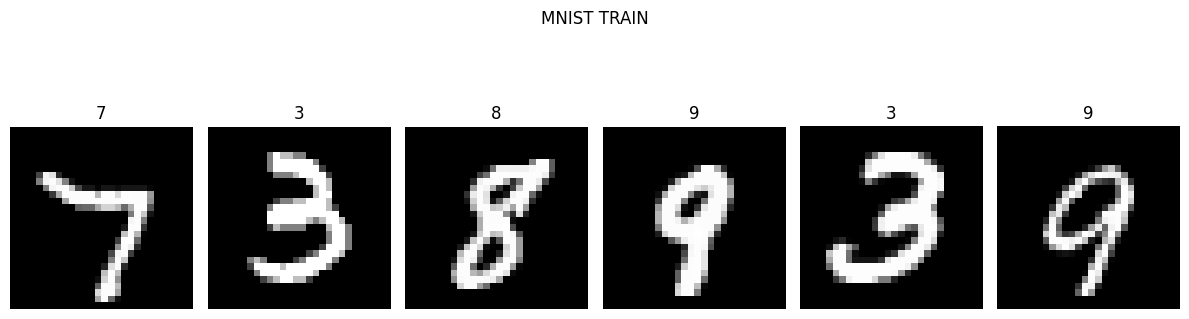

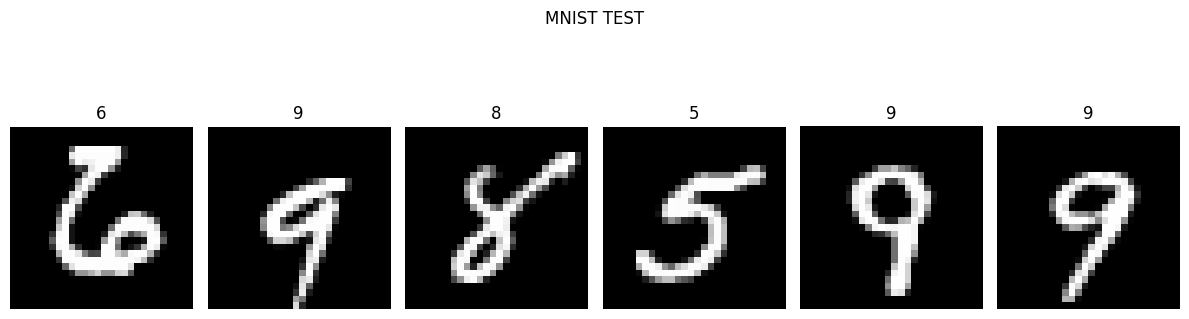

In [3]:
(X_train_MNIST, y_train_MNIST), (X_test_MNIST, y_test_MNIST) = mnist.load_data()

visualize_data(X_train_MNIST, y_train_MNIST, "MNIST TRAIN")
visualize_data(X_test_MNIST,  y_test_MNIST,  "MNIST TEST")

#### Data Splitting (Train, Validation, Test)

Pada tahap ini, dataset dibagi menjadi tiga bagian utama, yaitu training set, validation set, dan test set.

1. Training set
digunakan untuk melatih model dan update weight.

2. Validation set
digunakan untuk mengevaluasi performa model selama proses pelatihan serta membantu dalam pemilihan hyperparameter.

3. Test set
digunakan untuk mengukur performa akhir model terhadap data yang benar-benar belum pernah dilihat sebelumnya.

Proses pembagian dilakukan dengan cara shuffling data training. Setelah data diacak, sebagian data dipisahkan sebagai validation set, sementara sisanya digunakan sebagai training set.

In [4]:
VAL_SIZE_MNIST=10000
BATCH_SIZE_MNIST_MLP = 64
RANDOM_SEED_MNIST=67

np.random.seed(RANDOM_SEED_MNIST)          # make it reproducible
perm = np.random.permutation(len(X_train_MNIST))  # shuffled indices

X_train_MNIST = X_train_MNIST[perm]
y_train_MNIST = y_train_MNIST[perm]


X_val_MNIST = X_train_MNIST[-VAL_SIZE_MNIST:]
y_val_MNIST = y_train_MNIST[-VAL_SIZE_MNIST:]

X_train_MNIST = X_train_MNIST[:-VAL_SIZE_MNIST]
y_train_MNIST = y_train_MNIST[:-VAL_SIZE_MNIST]

print("Train:", X_train_MNIST.shape, y_train_MNIST.shape)
print("Val  :", X_val_MNIST.shape, y_val_MNIST.shape)
print("Test :", X_test_MNIST.shape, y_test_MNIST.shape)

Train: (50000, 28, 28) (50000,)
Val  : (10000, 28, 28) (10000,)
Test : (10000, 28, 28) (10000,)


<!-- #### Class Distribution -->
Sebelum melakukan proses definisi dan training, dilakukan analisis distribusi kelas pada dataset training dan testing untuk memastikan bahwa setiap kelas memiliki jumlah sampel yang seimbang.

In [5]:
class_distribution(y_train_MNIST, "TRAIN")
class_distribution(y_test_MNIST,  "TEST")
class_distribution(y_val_MNIST,  "VAL")


TRAIN class distribution:
Class 0:  4898  (0.098)
Class 1:  5599  (0.112)
Class 2:  4954  (0.099)
Class 3:  5131  (0.103)
Class 4:  4850  (0.097)
Class 5:  4510  (0.090)
Class 6:  4957  (0.099)
Class 7:  5266  (0.105)
Class 8:  4884  (0.098)
Class 9:  4951  (0.099)

TEST class distribution:
Class 0:   980  (0.098)
Class 1:  1135  (0.114)
Class 2:  1032  (0.103)
Class 3:  1010  (0.101)
Class 4:   982  (0.098)
Class 5:   892  (0.089)
Class 6:   958  (0.096)
Class 7:  1028  (0.103)
Class 8:   974  (0.097)
Class 9:  1009  (0.101)

VAL class distribution:
Class 0:  1025  (0.102)
Class 1:  1143  (0.114)
Class 2:  1004  (0.100)
Class 3:  1000  (0.100)
Class 4:   992  (0.099)
Class 5:   911  (0.091)
Class 6:   961  (0.096)
Class 7:   999  (0.100)
Class 8:   967  (0.097)
Class 9:   998  (0.100)


Nilai piksel dalam gambar biasanya berkisar antara 0 hingga 255. Nilai-nilai ini dinormalisasi ke rentang 0 hingga 1 dengan membagi setiap piksel dengan 255. Proses ini membantu network belajar dengan lebih efektif.

In [6]:
X_train_MNIST = X_train_MNIST.astype(np.float32) / 255.0
X_val_MNIST   = X_val_MNIST.astype(np.float32) / 255.0
X_test_MNIST  = X_test_MNIST.astype(np.float32) / 255.0

y_train_MNIST = y_train_MNIST.astype(np.int32)
y_val_MNIST   = y_val_MNIST.astype(np.int32)
y_test_MNIST  = y_test_MNIST.astype(np.int32)

#### Arsitektur Model MLP

1. **Input Layer (28x28)**  
   Layer untuk menerima citra berwarna 32×32 piksel.

2. **Flatten Layer**  
   Mengubah citra 2D menjadi vektor 1D berukuran 784.  
   setara dengan operasi NumPy:
      ```python
      x = x.reshape(-1, 28*28)
      ```
   
3. **Hidden Layer 1**  
   Melakukan ekstraksi fitur awal dari data input.
   - Dense 128, ReLU

4. **Hidden Layer 2**  
   Melakukan transformasi lanjutan untuk menyederhanakan fitur.
   - Dense 32, ReLU

5. **Output Layer (Dense 10, Softmax)**  
   Menghasilkan distribusi probabilitas kelas.
   - Dense 10, Softmax  

In [7]:
mlp_digit_classifier_model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),
    keras.layers.Flatten(), #the same as reshapeing to (784,)
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
], name="mlp_digit_classifier")

mlp_digit_classifier_model_initial_weights = mlp_digit_classifier_model.get_weights()
mlp_digit_classifier_model.summary()

Model: "mlp_digit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 32)                4128      
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 104938 (409.91 KB)
Trainable params: 104938 (409.91 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Model Callback
Callback merupakan objek atau fungsi yang digunakan untuk memantau dan mengontrol proses training model.    
Dalam proses training, digunakan beberapa callback untuk meningkatkan performa dan efisiensi pelatihan model, yaitu:

1. **Early Stopping**  
   Teknik yang menghentikan proses training secara otomatis ketika performa model pada validation set tidak lagi mengalami peningkatan.  
   Callback ini membantu mencegah overfitting dan menghindari pelatihan yang tidak perlu.

2. **Model Checkpoint**  
   Callback yang menyimpan model atau weight terbaik selama proses training berdasarkan metrik yang dipantau (misalnya validation loss atau validation accuracy).  
   Dengan callback ini, model terbaik dapat digunakan kembali tanpa perlu melakukan training ulang.


In [8]:
mlp_digit_classifier_model.set_weights(mlp_digit_classifier_model_initial_weights)

mlp_digit_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [9]:
mlp_digit_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mlp_digit_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/mlp_digit_classifier.{SAVE_FORMAT}', save_best_only=True, verbose=1, monitor='val_loss')

result = mlp_digit_classifier_model.fit(
    X_train_MNIST,               
    y_train_MNIST,               
    epochs=30, 
    batch_size=BATCH_SIZE_MNIST_MLP,
    validation_data=(X_val_MNIST, y_val_MNIST), 
    callbacks=[mlp_digit_classifier_model_early_stopping, mlp_digit_classifier_model_mcp],
)

Epoch 1/30


2026-02-19 16:01:44.171028: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x74a0ad153210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-19 16:01:44.171069: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
2026-02-19 16:01:44.178266: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-19 16:01:44.196005: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8905
2026-02-19 16:01:44.371994: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 [==============================] - ETA: 0s - loss: 0.3268 - accuracy: 0.9063
Epoch 1: val_loss improved from inf to 0.17733, saving model to /app/checkpoints/mlp_digit_classifier.h5
782/782 [==============================] - 9s 9ms/step - loss: 0.3268 - accuracy: 0.9063 - val_loss: 0.1773 - val_accuracy: 0.9490
Epoch 2/30
 16/782 [..............................] - ETA: 5s - loss: 0.1690 - accuracy: 0.9502

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


775/782 [============================>.] - ETA: 0s - loss: 0.1375 - accuracy: 0.9593
Epoch 2: val_loss improved from 0.17733 to 0.13630, saving model to /app/checkpoints/mlp_digit_classifier.h5
782/782 [==============================] - 6s 8ms/step - loss: 0.1373 - accuracy: 0.9593 - val_loss: 0.1363 - val_accuracy: 0.9613
Epoch 3/30
777/782 [============================>.] - ETA: 0s - loss: 0.0946 - accuracy: 0.9717
Epoch 3: val_loss improved from 0.13630 to 0.12228, saving model to /app/checkpoints/mlp_digit_classifier.h5
782/782 [==============================] - 7s 9ms/step - loss: 0.0947 - accuracy: 0.9717 - val_loss: 0.1223 - val_accuracy: 0.9642
Epoch 4/30
779/782 [============================>.] - ETA: 0s - loss: 0.0704 - accuracy: 0.9785
Epoch 4: val_loss improved from 0.12228 to 0.10470, saving model to /app/checkpoints/mlp_digit_classifier.h5
782/782 [==============================] - 6s 8ms/step - loss: 0.0704 - accuracy: 0.9785 - val_loss: 0.1047 - val_accuracy: 0.9692
Epo

Model terbaik akan diload untuk evaluasi dan prediksi pada data uji. 
Output model berupa vektor prediksi dimana masing-masing elemen menunjukkan **probabilitas kelas** (kelas 0–9) hasil **SoftMax**.  

In [10]:
mlp_digit_classifier_model.load_weights(f'{CKPT_PATH}/mlp_digit_classifier.{SAVE_FORMAT}')

test_loss, test_acc = mlp_digit_classifier_model.evaluate(X_test_MNIST, y_test_MNIST, verbose=0)

print(f"Test Accuracy: {test_acc * 100:.2f}%")


Test Accuracy: 97.48%


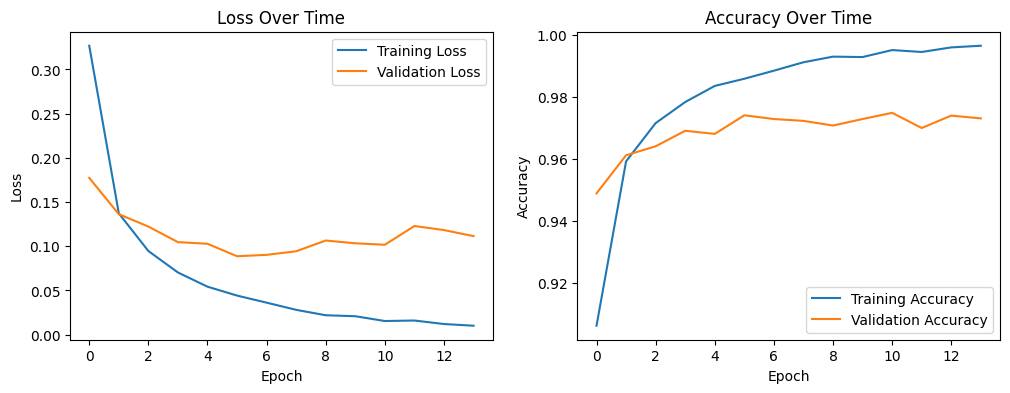

In [11]:
generate_plot(result)

Secara umum, MLP menghasilkan akurasi yang sangat tinggi pada data training dan cukup baik pada data validasi. Namun, terdapat selisih performa antara training dan validation yang menunjukkan generalisasi masih dapat ditingkatkan.

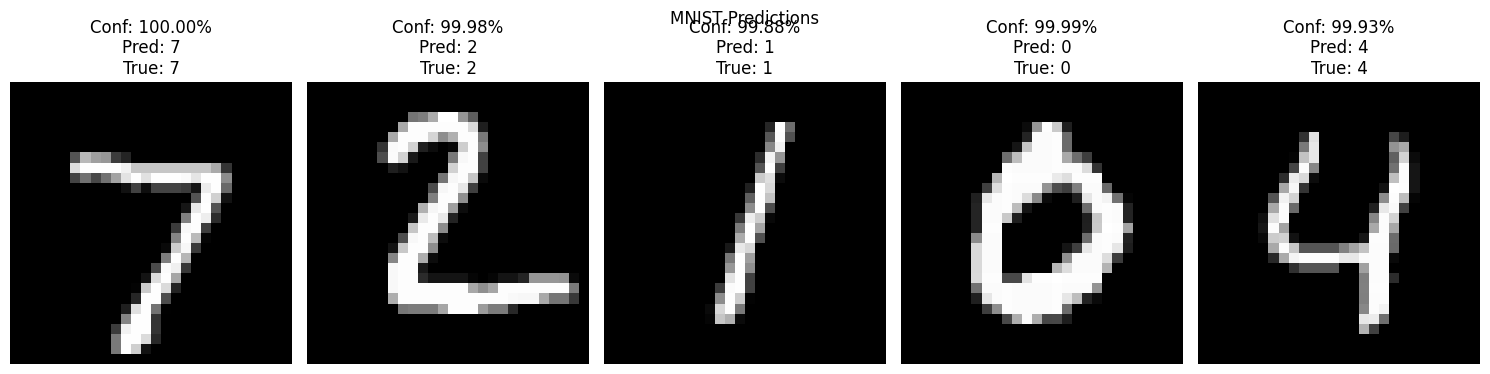

In [12]:
# Load best weights
mlp_digit_classifier_model_inference=keras.models.load_model(f"{CKPT_PATH}/mlp_digit_classifier.{SAVE_FORMAT}")

# Take 5 samples
X_vis = X_test_MNIST[:5]
y_true = y_test_MNIST[:5]

plot_predictions(
    mlp_digit_classifier_model_inference,
    X_vis,
    X_vis,
    y_true,
    img_shape=(28,28),
    title="MNIST Predictions"
)

<a id="2"></a>
## **2. Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus**
---

<a id=21></a>
### **2.1 Konsep CNN**

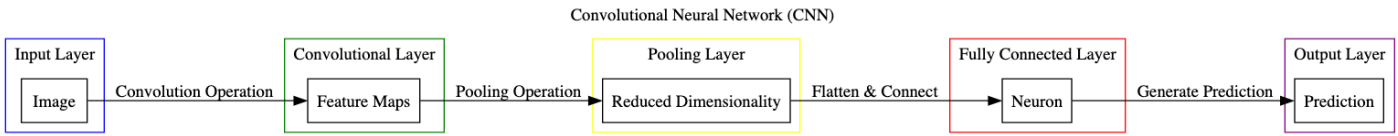

*Convolutional Neural Network (CNN)* adalah jenis khusus dari neural network yang
dirancang khusus untuk memproses data dengan struktur grid seperti gambar. CNN telah
sukses besar dalam berbagai aplikasi pengenalan gambar dan video.

**Struktur CNN**
1. **Input Layer**     
Layer ini terdiri dari neuron yang merepresentasikan setiap input fitur dalam data. Umumnya berupa gambar berbentuk B (Total / Batch image), C (Channel), H (Height), W (Width).
    ```python
    input_layer = layers.Input(shape=(H, W, C))
    ```

2. **Convolutional Layer**     
Layer konvolusi adalah inti dari CNN. Beberapa filter digunakan untuk melakukan konvolusi pada input. Hasilnya disebut feature map.  
    - Sebuah filter digeser di seluruh citra dan melakukan perkalian elemen demi elemen (dot product) dengan patch input.  
    - Fungsi aktivasi seperti **ReLU** biasanya diterapkan setelah konvolusi untuk menambahkan non-linearitas.  
    ```python
    conv_layer = layers.Conv2D(
        filters=32,         # jumlah filter/kernels
        kernel_size=(3, 3), # ukuran kernel
        strides=(1, 1),     # langkah pergeseran kernel
        padding='same',     # 'same' -> output feature map memiliki ukuran sama dengan input
        activation='relu'   # menggunakan fungsi aktivasi ReLU
    )
    ```

3. **Pooling Layer**       
Pooling layer bertujuan untuk mengurangi dimensionalitas data. Ada berbagai teknik pooling, termasuk max pooling, average pooling, dan sum pooling.      
Layer Max pooling mengambil nilai maksimum dari setiap area pooling window.
    ```python
    pool_layer = layers.MaxPooling2D(
        pool_size=(2, 2),  # ukuran pooling window
        strides=(2, 2),    # langkah pergeseran window
        padding='same'     # 'same' -> menambahkan padding jika ukuran input tidak genap
    )
    ```
4. **Fully Connected Layer**       
Fully connected layer menghubungkan setiap neuron di layer sebelumnya ke setiap neuron di layer berikutnya, mirip dengan apa yang terdapat pada MLP.    
Biasanya, fully connected layer ditempatkan di akhir arsitektur CNN, dan bertugas untuk menghasilkan prediksi akhir model.
    ```python
    hidden_layer = keras.layers.Dense(128, activation='relu')
    hidden_layer2 = keras.layers.Dense(32, activation='relu')
    output_layer = keras.layers.Dense(SIZE, activation="softmax")
    ```

#### **2.1.1 Proses Training CNN**

Proses pelatihan CNN serupa dengan MLP. Model dilatih menggunakan **backpropagation** dan algoritma optimasi seperti **Adam** atau **SGD**.  
Loss dihitung menggunakan fungsi seperti **cross-entropy**, kemudian weight dan bias diperbarui berdasarkan **algoritma optimasi**.


#### **2.1.2 Fungsi Aktivasi dalam CNN**

ReLU (Rectified Linear Unit) adalah fungsi aktivasi yang paling sering digunakan dalam
CNN.    
Fungsi ini mampu mempercepat konvergensi jaringan neural dibandingkan dengan
sigmoid atau tanh.

<a id=22></a>
### **2.2 Studi Kasus - MNIST CNN**
Berbeda dengan MLP yang hanya menggunakan layer fully connected, CNN dirancang untuk memanfaatkan struktur spasial pada data citra sehingga mampu mengekstraksi fitur secara lebih efektif.
Berikut merupakan kode implementasi model CNN:

#### Arsitektur Model CNN (Versi 1)

1. **Input Layer (28x28)**  
   Layer untuk menerima citra berwarna 32×32 piksel.

2. **Block 1**  
   Ekstraksi fitur lokal awal dari gambar.
   - Conv2D 32, kernel 3×3, ReLU  
   - Conv2D 32, kernel 3×3, ReLU  
   - MaxPooling 2×2  

3. **Block 2**  
   Ekstraksi fitur yang lebih kompleks dan representatif.
   - Conv2D 64, kernel 3×3, ReLU  
   - Conv2D 64, kernel 3×3, ReLU  
   - MaxPooling 2×2  

4. **Block 3**  
   Ekstraksi fitur tingkat tinggi dari gambar.
   - Conv2D 128, kernel 3×3, ReLU  
   - Conv2D 128, kernel 3×3, ReLU  
   - MaxPooling 2×2  

5. **Classifier**  
   Menghasilkan prediksi kelas.
   - Flatten  
   - Dense 128, ReLU  
   - Dense 10, Softmax  

In [13]:
# Create model
BATCH_SIZE_MNIST_CNN=64

cnn_digit_classifier_model = keras.Sequential([
    keras.Input(shape=(28,28,1)),
    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_digit_classifier")

cnn_digit_classifier_model_initial_weights = cnn_digit_classifier_model.get_weights()
cnn_digit_classifier_model.summary()

Model: "cnn_digit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                         

In [14]:
cnn_digit_classifier_model.set_weights(cnn_digit_classifier_model_initial_weights)

cnn_digit_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
    ,jit_compile=False
)

In [15]:
cnn_digit_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
cnn_digit_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/cnn_digit_classifier.{SAVE_FORMAT}', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = cnn_digit_classifier_model.fit(
    X_train_MNIST,               
    y_train_MNIST,               
    epochs=30, 
    batch_size=BATCH_SIZE_MNIST_CNN,
    validation_data=(X_val_MNIST, y_val_MNIST), 
    callbacks=[cnn_digit_classifier_model_early_stopping, cnn_digit_classifier_model_mcp],
)

Epoch 1/30
782/782 [==============================] - ETA: 0s - loss: 0.1499 - accuracy: 0.9526
Epoch 1: val_loss improved from inf to 0.06559, saving model to /app/checkpoints/cnn_digit_classifier.h5
782/782 [==============================] - 15s 15ms/step - loss: 0.1499 - accuracy: 0.9526 - val_loss: 0.0656 - val_accuracy: 0.9797
Epoch 2/30
782/782 [==============================] - ETA: 0s - loss: 0.0429 - accuracy: 0.9872
Epoch 2: val_loss improved from 0.06559 to 0.04841, saving model to /app/checkpoints/cnn_digit_classifier.h5
782/782 [==============================] - 11s 15ms/step - loss: 0.0429 - accuracy: 0.9872 - val_loss: 0.0484 - val_accuracy: 0.9844
Epoch 3/30
778/782 [============================>.] - ETA: 0s - loss: 0.0305 - accuracy: 0.9906
Epoch 3: val_loss improved from 0.04841 to 0.03976, saving model to /app/checkpoints/cnn_digit_classifier.h5
782/782 [==============================] - 11s 14ms/step - loss: 0.0308 - accuracy: 0.9905 - val_loss: 0.0398 - val_accurac

In [16]:
cnn_digit_classifier_model.load_weights(f'{CKPT_PATH}/cnn_digit_classifier.{SAVE_FORMAT}')
test_loss, test_acc = cnn_digit_classifier_model.evaluate(X_test_MNIST, y_test_MNIST, verbose=0)

print(f"Test Accuracy: {test_acc * 100:.2f}%")

Test Accuracy: 99.37%


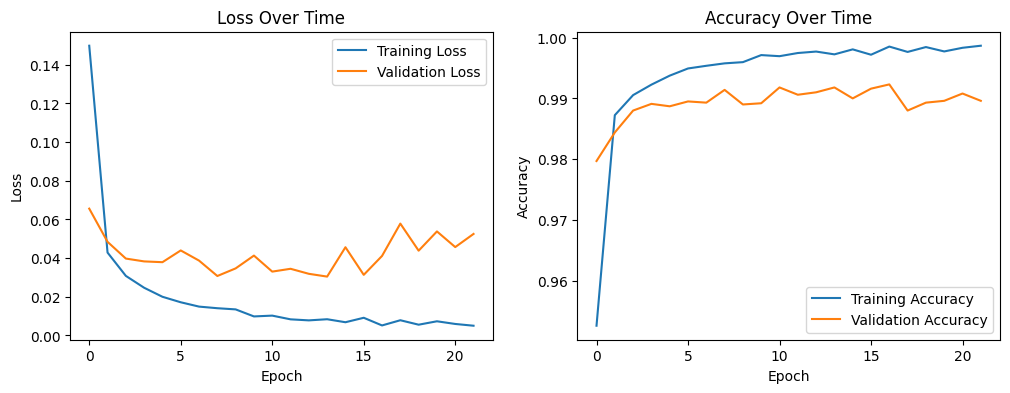

In [17]:
generate_plot(result)

Secara umum, CNN menghasilkan akurasi yang lebih tinggi dan lebih konsisten pada data validasi. Selisih antara training dan validation juga lebih kecil, model menunjukkan kemampuan generalisasi yang lebih baik dibandingkan MLP.

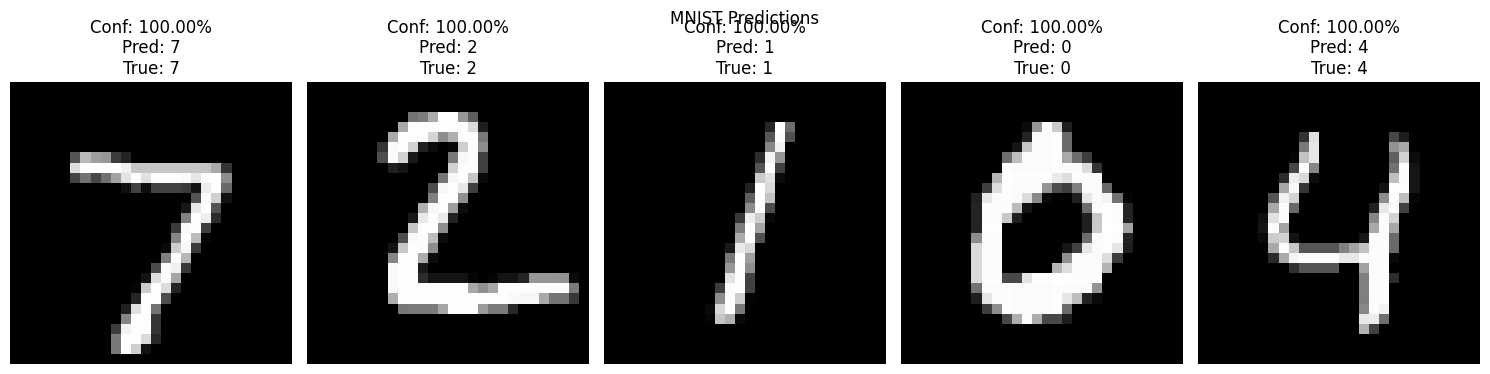

In [18]:
# Take 5 samples
cnn_digit_classifier_inference_model=keras.models.load_model(f"{CKPT_PATH}/cnn_digit_classifier.{SAVE_FORMAT}")

X_vis = X_test_MNIST[:5]
y_true = y_test_MNIST[:5]

plot_predictions(
    cnn_digit_classifier_inference_model,
    X_vis,
    X_vis,
    y_true,
    img_shape=(28,28),
    title="MNIST Predictions"
)

<a id="3"></a>
## **3. Penerapan MLP dan CNN pada data CIFAR-10**
---

<a id=31></a>
### **3.1 MLP CIFAR object classifier**

CIFAR-10 (Canadian Institute for Advanced Research) adalah dataset yang berisi kumpulan gambar berwarna untuk keperluan klasifikasi. Dataset ini terdiri dari **60.000 gambar berwarna 32×32 piksel**, yang terbagi menjadi **50.000 gambar untuk training** dan **10.000 gambar untuk testing**.  

Gambar-gambar ini dibagi menjadi **10 kelas** yang merepresentasikan objek umum, yaitu: pesawat terbang, mobil, burung, kucing, rusa, anjing, katak, kuda, kapal, dan truk.

Untuk memudahkan loading dan processing dataset digunakan **TensorFlow Datasets (TFDS)**. TFDS adalah library tensorflow yang menyediakan kumpulan dataset siap pakai untuk keperluan machine learning dan deep learning. Selain itu, TFDS memudahkan proses pengunduhan, pemrosesan, dan pemuatan dataset dalam format yang kompatibel dengan TensorFlow.

2026-02-19 16:07:33.091171: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-02-19 16:07:33.167448: W tensorflow/core/kernels/data/cache_dataset_ops.cc:854] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


CIFAR-10 Class Names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


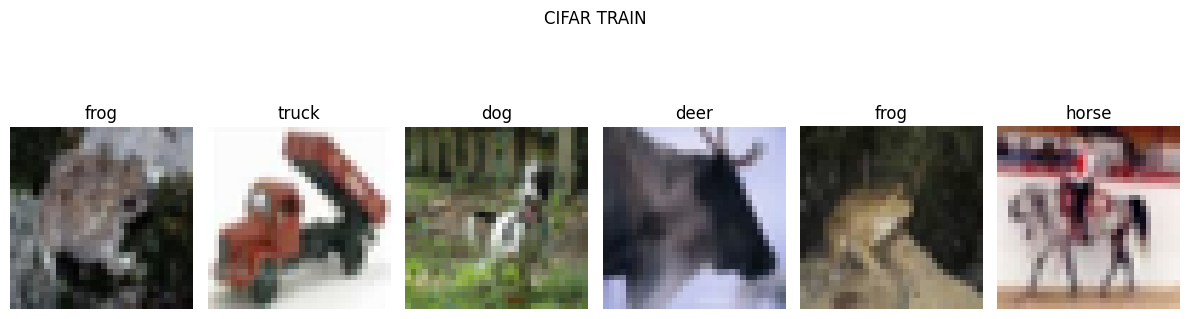

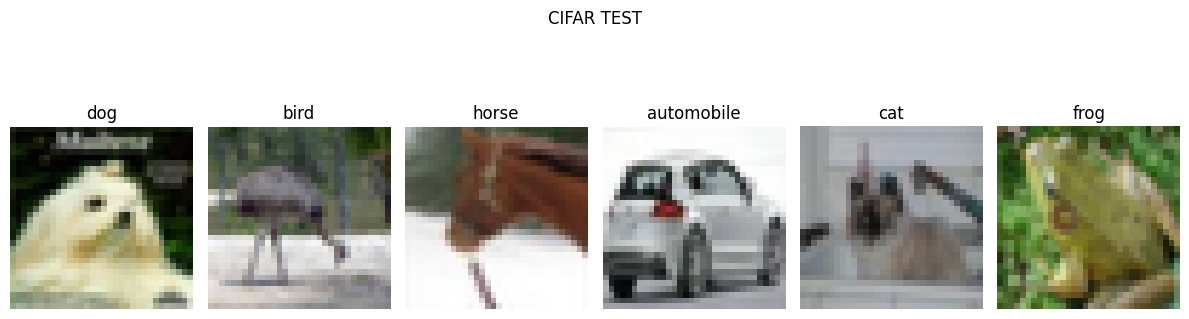

In [19]:

(train_ds_CIFAR, test_ds_CIFAR), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

CIFAR_CLASS = info.features["label"].names
X_vis_train_CIFAR = []
y_vis_train_CIFAR = []
X_vis_test_CIFAR = []
y_vis_test_CIFAR = []
for img, label in train_ds_CIFAR.take(10):
    X_vis_train_CIFAR.append(img)
    y_vis_train_CIFAR.append(label)
for img, label in test_ds_CIFAR.take(10):
    X_vis_test_CIFAR.append(img)
    y_vis_test_CIFAR.append(label)
print("CIFAR-10 Class Names:", CIFAR_CLASS)

X_vis_train_CIFAR = np.array([img.numpy() for img in X_vis_train_CIFAR])
y_vis_train_CIFAR = np.array([label.numpy() for label in y_vis_train_CIFAR])

X_vis_test_CIFAR = np.array([img.numpy() for img in X_vis_test_CIFAR])
y_vis_test_CIFAR = np.array([label.numpy() for label in y_vis_test_CIFAR])

visualize_data(X_vis_train_CIFAR, y_vis_train_CIFAR, "CIFAR TRAIN", class_names=CIFAR_CLASS)
visualize_data(X_vis_test_CIFAR, y_vis_test_CIFAR, "CIFAR TEST", class_names=CIFAR_CLASS)

train_ds_CIFAR dan test_ds_CIFAR adalah objek tf.data.Dataset, yaitu pipeline data TensorFlow yang berisi pasangan (image, label) dan dirancang untuk digunakan langsung dalam proses training model.

In [20]:
VAL_SIZE_CIFAR=10000
BATCH_SIZE_CIFAR=64
RANDOM_SEED_CIFAR=67


train_ds_CIFAR = train_ds_CIFAR.shuffle(10000, seed=RANDOM_SEED_CIFAR, reshuffle_each_iteration=False)

# Split
val_ds_CIFAR   = train_ds_CIFAR.take(VAL_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.skip(VAL_SIZE_CIFAR)

Selanjutnya, kembali dilakukan analisis distribusi kelas pada dataset training dan testing untuk memastikan bahwa setiap kelas memiliki jumlah sampel yang seimbang.

In [21]:
class_distribution(train_ds_CIFAR, "TRAIN")
class_distribution(test_ds_CIFAR,  "TEST")
class_distribution(val_ds_CIFAR,  "VAL")


TRAIN class distribution:
Class 0:  3980  (0.100)
Class 1:  4005  (0.100)
Class 2:  4020  (0.101)
Class 3:  4022  (0.101)
Class 4:  3986  (0.100)
Class 5:  3968  (0.099)
Class 6:  4014  (0.100)
Class 7:  3978  (0.099)
Class 8:  4006  (0.100)
Class 9:  4021  (0.101)

TEST class distribution:
Class 0:  1000  (0.100)
Class 1:  1000  (0.100)
Class 2:  1000  (0.100)
Class 3:  1000  (0.100)
Class 4:  1000  (0.100)
Class 5:  1000  (0.100)
Class 6:  1000  (0.100)
Class 7:  1000  (0.100)
Class 8:  1000  (0.100)
Class 9:  1000  (0.100)

VAL class distribution:
Class 0:  1020  (0.102)
Class 1:   995  (0.100)
Class 2:   980  (0.098)
Class 3:   978  (0.098)
Class 4:  1014  (0.101)
Class 5:  1032  (0.103)
Class 6:   986  (0.099)
Class 7:  1022  (0.102)
Class 8:   994  (0.099)
Class 9:   979  (0.098)


Dengan menggunakan TFDS (TensorFlow Datasets), beberapa langkah preprocessing dan optimisasi dapat dilakukan dengan mudah dan efisien. Berikut merupakan beberapa proses yang akan dilakukan apda dataset.

**1. Preprocessing (preprocess_ds_CIFAR):**
- Melakukan normalisasi input (x/255.0) dan casting label ke int32
- Menyiapkan data agar kompatibel dengan model (float32 input, int32 label)

**2. Mapping:**
- Menerapkan fungsi preprocess_ds_CIFAR ke setiap elemen dataset
- otomatis memanfaatkan CPU untuk mempercepat preprocessing

**3. Batching:**
- Mengelompokkan dataset menjadi batch sesuai batch size
- Setiap batch akan diproses model dalam satu forward-backward pass
- Memastikan input model tetap konsisten ukuran batch-nya

**4. Prefetching:**
- Memuat batch berikutnya di background saat model sedang training batch sekarang
- Mengurangi GPU/CPU idle time dan meningkatkan throughput pipeline

In [22]:
def preprocess_ds_CIFAR(x, y):
    x_new = tf.cast(x, tf.float32) / 255.0
    y_new = tf.cast(y, tf.int32)
    # print(f"Change shape from {x.shape} to {x_new.shape}")
    return x_new, y_new

# train_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_train_CIFAR, y_train_CIFAR))
train_ds_CIFAR = train_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_CIFAR = train_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

# val_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_val_CIFAR, y_val_CIFAR))
val_ds_CIFAR = val_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_CIFAR = val_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
val_ds_CIFAR = val_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

# test_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_test_CIFAR, y_test_CIFAR))
test_ds_CIFAR = test_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_CIFAR = test_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
test_ds_CIFAR = test_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

#### Arsitektur Model MLP

1. **Input Layer (32×32×3)**  
   Layer untuk menerima citra berwarna 32×32 piksel.

2. **Flatten Layer**  
   Mengubah citra 2D menjadi vektor 1D berukuran 3072.  
   
3. **Hidden Layer 1**  
   Melakukan ekstraksi fitur awal dari data input.
   - Dense 128, ReLU

4. **Hidden Layer 2**  
   Melakukan transformasi lanjutan untuk menyederhanakan fitur.
   - Dense 32, ReLU

5. **Output Layer (Dense 10, Softmax)**  
   Menghasilkan distribusi probabilitas kelas.
   - Dense 10, Softmax  

In [23]:
# Create model
mlp_object_classifier_model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
], name="mlp_object_classifier")
mlp_object_classifier_model_initial_weights = mlp_object_classifier_model.get_weights()
mlp_object_classifier_model.summary()


Model: "mlp_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 3072)              0         
                                                                 
 dense_5 (Dense)             (None, 128)               393344    
                                                                 
 dense_6 (Dense)             (None, 32)                4128      
                                                                 
 dense_7 (Dense)             (None, 10)                330       
                                                                 
Total params: 397802 (1.52 MB)
Trainable params: 397802 (1.52 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:

mlp_object_classifier_model.set_weights(mlp_object_classifier_model_initial_weights)

mlp_object_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=False
)
mlp_object_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mlp_object_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/mlp_object_classifier.{SAVE_FORMAT}', save_best_only=True, verbose=1, monitor='val_loss')

result = mlp_object_classifier_model.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[mlp_object_classifier_model_early_stopping, mlp_object_classifier_model_mcp],
)

Epoch 1/30
623/625 [============================>.] - ETA: 0s - loss: 2.0039 - accuracy: 0.2666
Epoch 1: val_loss improved from inf to 1.84914, saving model to /app/checkpoints/mlp_object_classifier.h5
625/625 [==============================] - 7s 8ms/step - loss: 2.0030 - accuracy: 0.2668 - val_loss: 1.8491 - val_accuracy: 0.3389
Epoch 2/30
623/625 [============================>.] - ETA: 0s - loss: 1.7823 - accuracy: 0.3630
Epoch 2: val_loss improved from 1.84914 to 1.76514, saving model to /app/checkpoints/mlp_object_classifier.h5
625/625 [==============================] - 5s 8ms/step - loss: 1.7817 - accuracy: 0.3632 - val_loss: 1.7651 - val_accuracy: 0.3718
Epoch 3/30
624/625 [============================>.] - ETA: 0s - loss: 1.7027 - accuracy: 0.3938
Epoch 3: val_loss improved from 1.76514 to 1.72598, saving model to /app/checkpoints/mlp_object_classifier.h5
625/625 [==============================] - 5s 8ms/step - loss: 1.7023 - accuracy: 0.3939 - val_loss: 1.7260 - val_accuracy: 

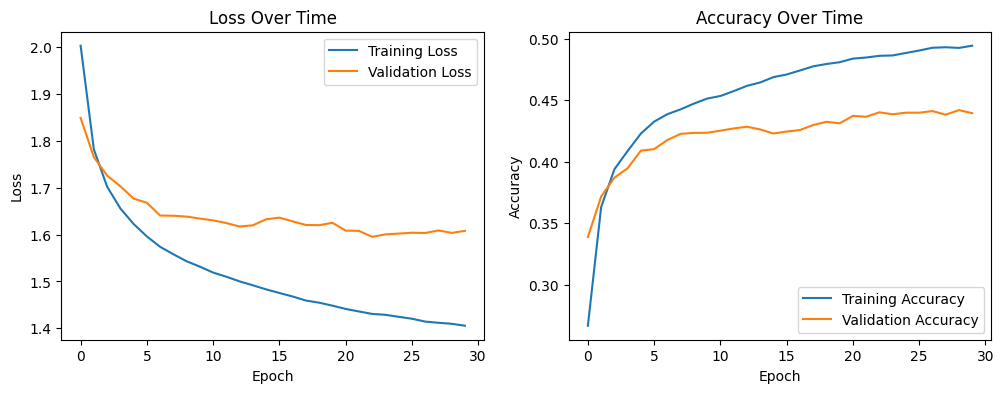

In [25]:
# Plot training history
generate_plot(result)

Untuk CIFAR, MLP menghasilkan akurasi yang kurang tinggi dalam training dan validasi karena model ini tidak bisa menangkap pola spasial dalam gambar yang lebih kompleks secara efektif. 

In [26]:
# Evaluate model
mlp_object_classifier_model.load_weights(f'{CKPT_PATH}/mlp_object_classifier.{SAVE_FORMAT}')
test_loss_CIFAR, test_acc_CIFAR = mlp_object_classifier_model.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")


157/157 [==============================] - 1s 3ms/step - loss: 1.5592 - accuracy: 0.4524
Test Accuracy: 45.24%


(5, 32, 32, 3)
(5, 1)


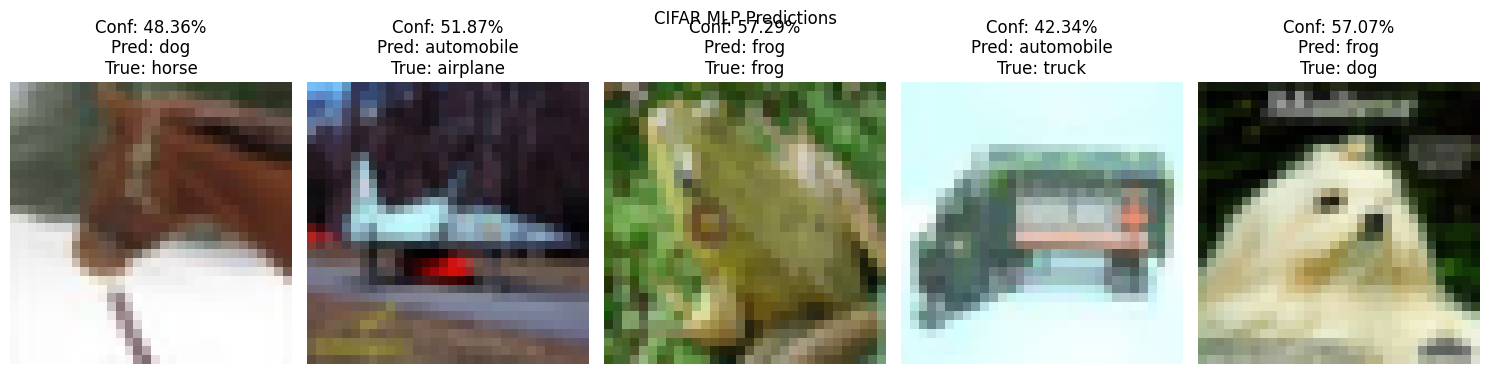

In [27]:
mlp_object_classifier_inference_model=keras.models.load_model(f"{CKPT_PATH}/mlp_object_classifier.{SAVE_FORMAT}")

num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32)
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    mlp_object_classifier_inference_model,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    class_names=CIFAR_CLASS,
    img_shape=(32,32,3),
    title="CIFAR MLP Predictions"
)

<a id=32></a>
### **3.2 CNN CIFAR object classifier 1**

#### Arsitektur Model CNN (Versi 1)

1. **Input Layer (32×32×3)**  
   Layer untuk menerima citra berwarna 32×32 piksel.

2. **Block 1**  
   Ekstraksi fitur lokal awal dari gambar.
   - Conv2D 32, kernel 3×3, ReLU  
   - Conv2D 32, kernel 3×3, ReLU  
   - MaxPooling 2×2  

3. **Block 2**  
   Ekstraksi fitur yang lebih kompleks dan representatif.
   - Conv2D 64, kernel 3×3, ReLU  
   - Conv2D 64, kernel 3×3, ReLU  
   - MaxPooling 2×2  

4. **Block 3**  
   Ekstraksi fitur tingkat tinggi dari gambar.
   - Conv2D 128, kernel 3×3, ReLU  
   - Conv2D 128, kernel 3×3, ReLU  
   - MaxPooling 2×2  

5. **Classifier**  
   Menghasilkan prediksi kelas.
   - Flatten  
   - Dense 128, ReLU  
   - Dense 10, Softmax  

In [28]:
cnn_object_classifier_model = keras.Sequential([
    keras.Input(shape=(32,32,3)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_object_classifier")

cnn_object_classifier_model_initial_weights = cnn_object_classifier_model.get_weights()
cnn_object_classifier_model.summary()

Model: "cnn_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 conv2d_7 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_9 (Conv2D)           (None, 16, 16, 64)        36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                        

In [29]:
# Reset weights
cnn_object_classifier_model.set_weights(cnn_object_classifier_model_initial_weights)

# Compile model
cnn_object_classifier_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=False
)
# Define callbacks
cnn_object_classifier_model_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
cnn_object_classifier_model_mcp = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_classifier.{SAVE_FORMAT}', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = cnn_object_classifier_model.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[cnn_object_classifier_model_early_stopping, cnn_object_classifier_model_mcp],
)

Epoch 1/30
623/625 [============================>.] - ETA: 0s - loss: 1.6047 - accuracy: 0.4077
Epoch 1: val_loss improved from inf to 1.28116, saving model to /app/checkpoints/cnn_object_classifier.h5
625/625 [==============================] - 13s 16ms/step - loss: 1.6033 - accuracy: 0.4083 - val_loss: 1.2812 - val_accuracy: 0.5450
Epoch 2/30
623/625 [============================>.] - ETA: 0s - loss: 1.0748 - accuracy: 0.6164
Epoch 2: val_loss improved from 1.28116 to 0.94826, saving model to /app/checkpoints/cnn_object_classifier.h5
625/625 [==============================] - 9s 15ms/step - loss: 1.0740 - accuracy: 0.6166 - val_loss: 0.9483 - val_accuracy: 0.6593
Epoch 3/30
622/625 [============================>.] - ETA: 0s - loss: 0.8508 - accuracy: 0.6996
Epoch 3: val_loss improved from 0.94826 to 0.84414, saving model to /app/checkpoints/cnn_object_classifier.h5
625/625 [==============================] - 10s 15ms/step - loss: 0.8498 - accuracy: 0.6999 - val_loss: 0.8441 - val_accur

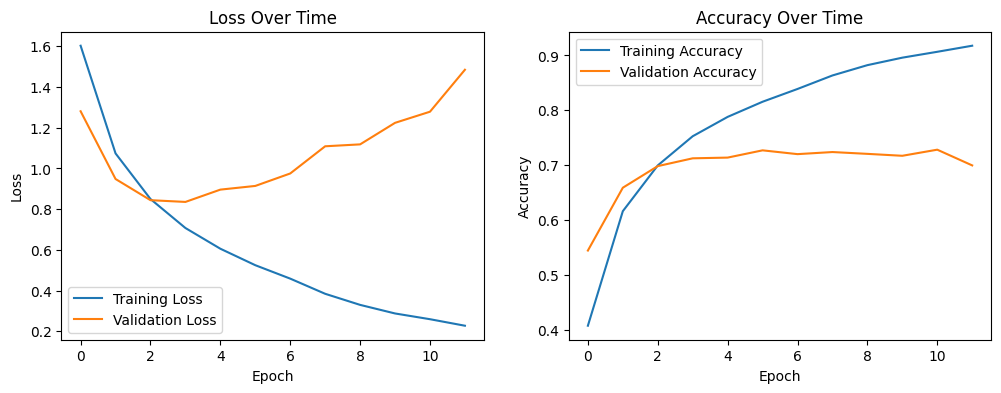

In [30]:
# Plot training history
generate_plot(result)

Untuk CIFAR, CNN mampu menangkap pola spasial dalam gambar, tetapi model tersebut mengalami overfitting, sehingga akurasi pada data training sangat tinggi sementara performa pada data test menurun drastis. 

Overfitting ini menunjukkan bahwa model terlalu menghafalkan fitur data training dan gagal menggeneralisasi ke data baru. 
Strategi seperti mengurangi jumlah layer, menambahkan dropout, dan menerapkan regularisasi dapat membantu mengurangi overfitting dan meningkatkan generalisasi model.

In [31]:
# Evaluate model
cnn_object_classifier_model.load_weights(f'{CKPT_PATH}/cnn_object_classifier.{SAVE_FORMAT}')
test_loss_CIFAR, test_acc_CIFAR = cnn_object_classifier_model.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")

157/157 [==============================] - 1s 5ms/step - loss: 0.8357 - accuracy: 0.7119
Test Accuracy: 71.19%


(5, 32, 32, 3)
(5, 1)


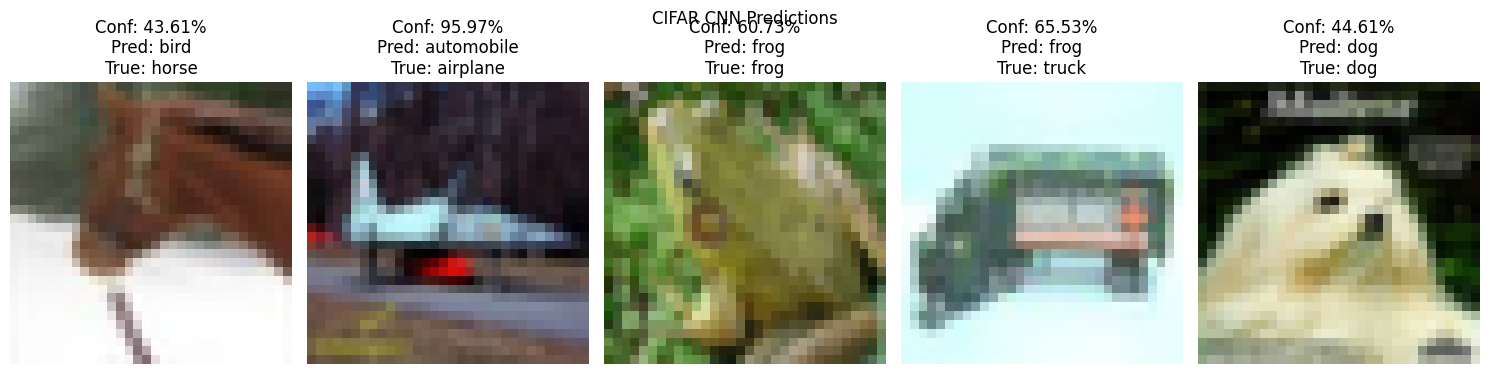

In [32]:
cnn_object_classifier_inference_model=keras.models.load_model(f"{CKPT_PATH}/cnn_object_classifier.{SAVE_FORMAT}")

num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32)
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    cnn_object_classifier_inference_model,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    img_shape=(32,32,3),
    class_names=CIFAR_CLASS,
    cmap=None,
    title="CIFAR CNN Predictions"
)


<a id=33></a>
### **3.3 CNN CIFAR object classifier 2**

#### Arsitektur Model CNN (Versi 2 – Dengan BatchNorm & Dropout)

1. **Input Layer (32×32×3)**  
   Layer untuk menerima citra berwarna 32×32 piksel.

2. **Block 1**  
   - Conv2D 32, kernel 3×3, ReLU
   - BatchNormalization  
   - Conv2D 32, kernel 3×3, ReLU 
   - BatchNormalization  
   - MaxPooling 2×2  
   - Dropout 0.2  
   Ekstraksi fitur lokal dan menstabilkan distribusi aktivasi.

3. **Block 2**  
   - Conv2D 64, kernel 3×3, ReLU
   - BatchNormalization  
   - Conv2D 64, kernel 3×3, ReLU
   - BatchNormalization  
   - MaxPooling 2×2  
   - Dropout 0.4  
   Ekstraksi fitur kompleks dengan regularisasi tambahan.

4. **Block 3**  
   - Conv2D 128, kernel 3×3, ReLU
   - BatchNormalization  
   - Conv2D 128, kernel 3×3, ReLU
   - BatchNormalization  
   - MaxPooling 2×2  
   - Dropout 0.5  
   Ekstraksi fitur abstrak dengan regularisasi untuk mengurangi overfitting.

5. **Classifier**  
   - Flatten  
   - Dense 128, ReLU → BatchNormalization
   - Dropout 0.5  
   - Dense 10, Softmax  
   Menghasilkan prediksi probabilitas kelas CIFAR.

**Dropout** dan **Batch Normalization** merupakan teknik yang sering digunakan dalam CNN untuk membantu proses training menjadi lebih stabil dan mencegah overfitting:

1. **Dropout** adalah teknik regularisasi yang digunakan untuk mencegah overfitting pada neural network.  
    - Saat training, **sebagian neuron secara acak dinonaktifkan** pada setiap batch, saat inference 
    ,semua neuron digunakan, namun output biasanya dikalibrasi sesuai probabilitas dropout.
    - Tujuannya agar jaringan tidak terlalu bergantung pada neuron tertentu dan belajar **representasi fitur yang lebih general**.  

2. **Batch Normalization** menormalkan aktivasi di setiap layer untuk **mempercepat dan menstabilkan training**.  
    - Setiap batch, output layer diubah sehingga memiliki **mean ≈ 0** dan **variance ≈ 1**.  
    - Membantu model lebih tahan terhadap variasi weight awal dan learning rate yang lebih besar.  

In [33]:

cnn_object_classifier_model_v2 = keras.Sequential([
    keras.Input(shape=(32,32,3)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.4),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPool2D(2),
    keras.layers.Dropout(0.5),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_object_classifier_v2")

cnn_object_classifier_model_v2_initial_weights = cnn_object_classifier_model_v2.get_weights()
cnn_object_classifier_model_v2.summary()

Model: "cnn_object_classifier_v2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_12 (Conv2D)          (None, 32, 32, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 32, 32, 32)        128       
 Normalization)                                                  
                                                                 
 conv2d_13 (Conv2D)          (None, 32, 32, 32)        9248      
                                                                 
 batch_normalization_1 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                          

In [34]:
cnn_object_classifier_model_v2.set_weights(cnn_object_classifier_model_v2_initial_weights)

cnn_object_classifier_model_v2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=False
)
cnn_object_classifier_model_v2_early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
cnn_object_classifier_model_v2_mcp = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_classifier_v2.{SAVE_FORMAT}', save_best_only=True, verbose=1, monitor='val_loss')

result = cnn_object_classifier_model_v2.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[cnn_object_classifier_model_v2_early_stopping, cnn_object_classifier_model_v2_mcp],
)

Epoch 1/30


2026-02-19 16:12:26.001538: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_object_classifier_v2/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


625/625 [==============================] - ETA: 0s - loss: 1.7776 - accuracy: 0.3949
Epoch 1: val_loss improved from inf to 1.45256, saving model to /app/checkpoints/cnn_object_classifier_v2.h5
625/625 [==============================] - 20s 23ms/step - loss: 1.7776 - accuracy: 0.3949 - val_loss: 1.4526 - val_accuracy: 0.4880
Epoch 2/30
624/625 [============================>.] - ETA: 0s - loss: 1.1902 - accuracy: 0.5759
Epoch 2: val_loss improved from 1.45256 to 1.20247, saving model to /app/checkpoints/cnn_object_classifier_v2.h5
625/625 [==============================] - 14s 22ms/step - loss: 1.1896 - accuracy: 0.5761 - val_loss: 1.2025 - val_accuracy: 0.5856
Epoch 3/30
625/625 [==============================] - ETA: 0s - loss: 0.9920 - accuracy: 0.6522
Epoch 3: val_loss improved from 1.20247 to 0.97095, saving model to /app/checkpoints/cnn_object_classifier_v2.h5
625/625 [==============================] - 14s 22ms/step - loss: 0.9920 - accuracy: 0.6522 - val_loss: 0.9709 - val_accura

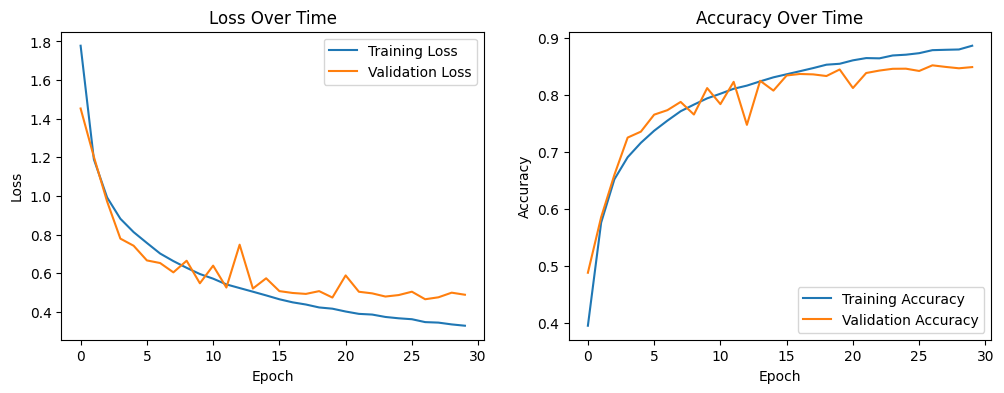

In [35]:
generate_plot(result)

Untuk CIFAR CNN versi 2 dapat terlihat menggunakan **Dropout** dan **Batch Normalization** meningkatkan kemampuan generalisasi model. Kombinasi kedua teknik ini menghasilkan model yang tidak hanya memiliki akurasi training yang tinggi, tetapi juga performa test yang lebih baik.

In [36]:
cnn_object_classifier_model_v2.load_weights(f'{CKPT_PATH}/cnn_object_classifier_v2.{SAVE_FORMAT}')
test_loss_CIFAR, test_acc_CIFAR = cnn_object_classifier_model_v2.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")

157/157 [==============================] - 1s 6ms/step - loss: 0.4744 - accuracy: 0.8470
Test Accuracy: 84.70%


(5, 32, 32, 3)
(5, 1)


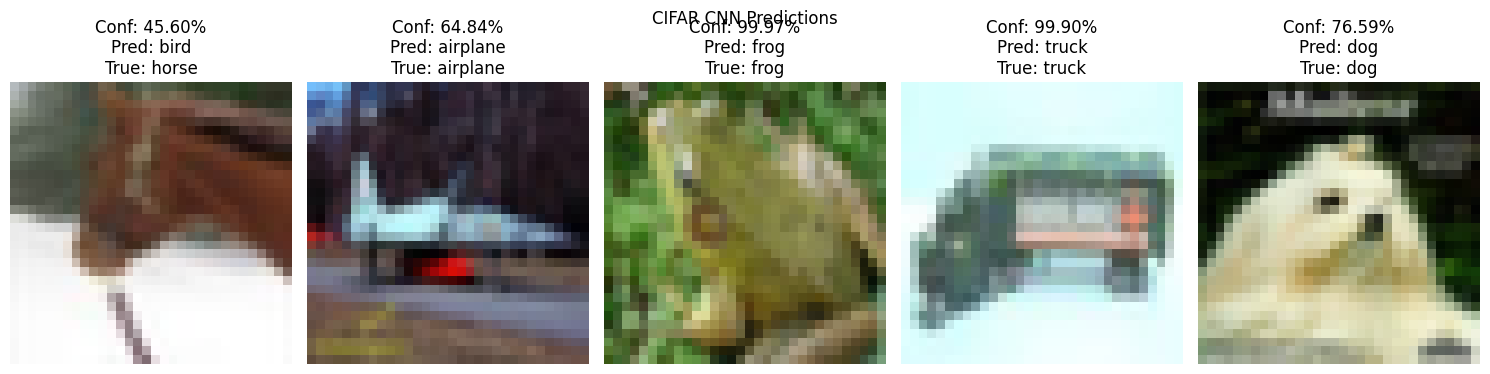

In [37]:
cnn_object_classifier_inference_model_v2=keras.models.load_model(f"{CKPT_PATH}/cnn_object_classifier_v2.{SAVE_FORMAT}")

num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32)
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

plot_predictions(
    cnn_object_classifier_inference_model_v2,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    img_shape=(32,32,3),
    class_names=CIFAR_CLASS,
    cmap=None,
    title="CIFAR CNN Predictions"
)


<a id="4"></a>
## **4. Kesimpulan dan Bacaan Lanjutan**
---

Model CNN berhasil diterapkan untuk klasifikasi gambar **CIFAR-10** dan **MNIST**.  
Dengan arsitektur yang digunakan, model mencapai akurasi yang cukup baik pada data uji, menandakan kemampuan jaringan dalam **menangkap pola spasial** dan **mengenali digit atau objek kecil**.  

Beberapa hal yang dapat dilakukan untuk meningkatkan performa model:  
- **Data augmentation**: rotasi, flipping, cropping, dan perubahan warna untuk memperluas variasi dataset.  
- **Arsitektur lebih kompleks**: menambahkan layer Conv2D, Dense, atau menggunakan residual connection.  
- **Regularisasi tambahan**: Dropout, L2 regularization, atau Batch Normalization untuk mengurangi overfitting.  
- **Optimasi training**: Early stopping, learning rate scheduling, dan penggunaan optimizer lainnya.  

Selamat belajar dan bereksperimen dengan Deep learning! 🚀

<a id="41"></a>
### Bacaan lanjutan
- [Early Stopping to Avoid Overtraining Neural Network Models](https://machinelearningmastery.com/early-stopping-to-avoid-overtraining-neural-network-models/)  
- [TensorFlow Datasets API Documentation](https://www.tensorflow.org/datasets/api_docs/python/tfds)  
- [TensorFlow CNN Guide](https://www.tensorflow.org/tutorials/images/cnn)  
- [CIFAR-10 Dataset Overview](https://www.cs.toronto.edu/~kriz/cifar.html)  
- [Dropout: A Simple Way to Prevent Neural Networks from Overfitting](https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf)  
- [Dropout Regularization in Deep Learning Models with Keras](https://machinelearningmastery.com/dropout-regularization-deep-learning-models-keras/)
